In [127]:
import matplotlib.pyplot as plt

In [128]:
# Example: Define J_k with predefined coverage sets
# J_k[k] = list of post indices j that can cover hotspot k
J_k = {
    0: [0, 2],  # Hotspot 0 can be covered by posts 0 and 2
    1: [1],     # Hotspot 1 can be covered by post 1
    2: [0, 1, 2] # Hotspot 2 can be covered by any post
}
print("J_k (predefined):", J_k)

J_k (predefined): {0: [0, 2], 1: [1], 2: [0, 1, 2]}


### Predefined Coverage Sets for Hotspots

In some scenarios, the set of ambulance posts that can cover each call hotspot ($J^{(*k)}$) is determined by policy, operational constraints, or historical data, rather than by a simple distance rule. In this case, you can define $J^{(*k)}$ as a dictionary where each hotspot $k$ maps to a list of post indices $j$ that are allowed to cover it.

This approach allows for maximum flexibility and can reflect real-world constraints or expert knowledge.

### Linear integer program

Let $I = \{0,\dots,\text{num\_ambulances}-1\}$ and $J = \{0,\dots,|\text{ambulance\_posts}|-1\}$ and $K = \{0,\dots,|\text{call\_hotspots}|-1\}$.

Decision variable:

- $x_{ij} \in \{0,1\}$, equal to 1 if ambulance $i$ is assigned to post $j$.
- $y_{k} \in \{0,1\}$, equal to 1 if call hotspot $k$ is "covered" by at least one ambulance (this is enforced by constraints).

Parameters:
- $c_{ij}$ cost of ambulanc $i$ moving to post $j$ (distance travelled but shift change cost)
- $b_{k}$ intensity of call hotspot (for example average number of calls during time period)

Objective:

$$
\min \sum_{i \in I} \sum_{j \in J} (c_{ij}) x_{ij} - \sum_{k \in K} (b_k) y_k
$$

Constraints

Each ambulance assigned once:

$$
\sum_{j \in J} x_{ij} = 1, \quad \forall i \in I
$$

Call hotspot covered constraint, where $J^{(*k)} \subseteq J$ is the subset $\{j \in J \text{ given ambulance post } j \text{ covers call hotspot k}  \}$:

$$
\sum_{j \in J^{(*k)}} x_{ij} \geq y_k, \quad \forall k \in K
$$


<!-- Optional post capacity / load balancing requirement constraint:

$$
\sum_{i \in I} x_{ij} \le U_j, \quad \forall j \in J
$$ -->

Possible to denote diminisihing award for coverage. For example assume $z_k$ is either 1 or 0. This constraint ensures it is $1$ only when there are at least 2 ambulances in the coverage spot:

$$
\sum_{j \in J^{(*k)}} x_{ij} \geq z_k - 1, \quad \forall k \in K
$$


In [129]:
import pulp
def build_ambulance_integer_program(num_ambulances, ambulance_posts, c, b, J_k, post_capacity=None):
    I = range(num_ambulances)
    J = range(len(ambulance_posts))
    K = range(len(b))

    model = pulp.LpProblem("AmbulancePostAssignment", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("x", (I, J), lowBound=0, upBound=1, cat="Binary")
    y = pulp.LpVariable.dicts("y", K, lowBound=0, upBound=1, cat="Binary")

    # Accept c as a 2D list: c[i][j]
    model += (
        pulp.lpSum(c[i][j] * x[i][j] for i in I for j in J)
        - pulp.lpSum(b[k] * y[k] for k in K)
    )

    for i in I:
        model += pulp.lpSum(x[i][j] for j in J) == 1

    for k in K:
        covering_posts = J_k.get(k, [])
        model += pulp.lpSum(x[i][j] for i in I for j in covering_posts) >= y[k]

    if post_capacity is not None:
        for j in J:
            model += pulp.lpSum(x[i][j] for i in I) <= post_capacity[j]

    return model, x, y

In [130]:
hosptials = [(0,0), (0,10), (10,10), (10,0)]
ambulance_posts = [(0, 3), (10, 7), (1, 10)]
call_hotspots = [(0, 4), (9, 8), (2, 10)]
num_ambulances = 5
b = [8, 6, 10]

# J_k[k] = list of post indices j that can cover hotspot k
J_k = {
    0: [0],
    1: [1],
    2: [2],
}

In [131]:
import math

def euclidean_distance(a, b):
    return math.dist(a, b)


print("b =", b)
print("J_k =", J_k)

b = [8, 6, 10]
J_k = {0: [0], 1: [1], 2: [2]}


In [132]:
from collections import defaultdict
def plot_assignments_with_table(ambulance_posts, call_hotspots, assignments, num_ambulances, print_details=True):
    plt.figure(figsize=(8, 8))
    # Plot ambulance posts
    for idx, post in enumerate(ambulance_posts):
        plt.scatter(post[0], post[1], c='blue', marker='s', s=100, label='Ambulance Post' if idx == 0 else "")
        plt.text(post[0]+0.1, post[1]+0.1, f'P{idx}', color='blue')
    # Plot call hotspots
    for idx, hotspot in enumerate(call_hotspots):
        plt.scatter(hotspot[0], hotspot[1], c='red', marker='*', s=150, label='Hotspot' if idx == 0 else "")
        plt.text(hotspot[0]+0.1, hotspot[1]+0.1, f'H{idx}', color='red')
    # Plot ambulances as lighter green triangles at their assigned posts
    assigned_posts = [post for _, post in assignments]
    for amb_idx, post_idx in enumerate(assigned_posts):
        post = ambulance_posts[post_idx]
        plt.scatter(post[0], post[1], c='#90ee90', marker='^', s=120, label='Ambulance' if amb_idx == 0 else "")
        plt.text(post[0]-0.2, post[1]-0.2, f'A{amb_idx}', color='#228B22')
    plt.legend()
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Ambulance Posts, Hotspots, and Assignments')
    plt.grid(True)
    plt.show()
    # Create a summary dictionary of assignments indexed by post
    post_to_ambulances = defaultdict(list)
    for amb, post in assignments:
        post_to_ambulances[post].append(amb)
    if print_details:
        print("Ambulance assignments by post:")
        for post_idx in range(len(ambulance_posts)):
            loc = ambulance_posts[post_idx]
            assigned_ambs = post_to_ambulances.get(post_idx, [])
            print(f"Post {post_idx} at {loc}: {assigned_ambs if assigned_ambs else 'No ambulances assigned'}")
    return dict(post_to_ambulances)

In [160]:
import math
def calculate_c(ambulance_assignments, ambulance_posts, t):
    """
    Calculate c values for each ambulance and post at timestep t.
    ambulance_assignments: list of current post indices for each ambulance (len=num_ambulances)
    ambulance_posts: list of post locations [(x, y), ...]
    t: current timestep (not used in this simple version, but included for future extension)
    Returns: c as a 2D list, where c[i][j] is the distance from ambulance i's current post to post j
    """
    num_ambulances = len(ambulance_assignments)
    num_posts = len(ambulance_posts)
    c = []
    for i in range(num_ambulances):
        current_post = ambulance_assignments[i]
        current_loc = ambulance_posts[current_post]
        row = []
        for j in range(num_posts):
            target_loc = ambulance_posts[j]
            dist = math.dist(current_loc, target_loc)
            row.append(dist)
        c.append(row)
    return c

def calculate_b(ambulance_assignments, ambulance_posts, t):
    """
    Hardcoded b values for 5 hospitals and 5 hotspots, ignoring inputs.
    Returns: b as a list of length 5.
    """
    # Example hardcoded values (can be changed as needed)
    b = [
        [0, 1, 0, 1, 1],
        [1, 1, 1, 1, 1],
        [19, 1, 10, 1, 1],
        [20, 1, 20, 1, 1],
        [0, 0, 20, 40, 20],
    ]

    return b[t % 5]  # Just return a row based on timestep for demonstration

## Simulation Example: 5 Hospitals, 5 Ambulance Posts, 5 Hotspots
This section demonstrates the simulation with a toy example. Five hospitals are placed at the vertices of a pentagon, each more than 10 units apart. Five ambulance posts are co-located with the hospitals, and five call hotspots are placed near each post. The coverage set $J_k$ is defined so that hotspot $k$ is covered only by post $k$.

In [156]:
def run_simulation(num_timesteps, num_ambulances, ambulance_posts, call_hotspots, J_k, calculate_c_fn, calculate_b_fn):
    """
    Runs a simulation for num_timesteps, updating assignments and displaying plots for each timestep.
    Displays all plots side by side with a limit of 3 per row.
    ambulance_posts: list of post locations [(x, y), ...]
    call_hotspots: list of hotspot locations [(x, y), ...]
    J_k: dict mapping hotspot index to list of post indices that can cover it
    calculate_c_fn: function to calculate c
    calculate_b_fn: function to calculate b
    """
    assignments_history = []
    ambulance_assignments = None
    # Prepare to collect all plot data
    plot_data = []
    for t in range(num_timesteps):
        if t == 0:
            c = [[0 for _ in range(len(ambulance_posts))] for _ in range(num_ambulances)]
            b = calculate_b_fn([0]*num_ambulances, ambulance_posts, t)
            model, x, y = build_ambulance_integer_program(num_ambulances, ambulance_posts, c, b, J_k)
            status = model.solve(pulp.PULP_CBC_CMD(msg=False))
            assignments = [(i, j) for i in range(num_ambulances) for j in range(len(ambulance_posts)) if pulp.value(x[i][j]) > 0.5]
            ambulance_assignments = [j for i, j in assignments]
        else:
            c = calculate_c_fn(ambulance_assignments, ambulance_posts, t)
            b = calculate_b_fn(ambulance_assignments, ambulance_posts, t)
            model, x, y = build_ambulance_integer_program(num_ambulances, ambulance_posts, c, b, J_k)
            status = model.solve(pulp.PULP_CBC_CMD(msg=False))
            assignments = [(i, j) for i in range(num_ambulances) for j in range(len(ambulance_posts)) if pulp.value(x[i][j]) > 0.5]
            ambulance_assignments = [j for i, j in assignments]
        assignments_history.append(assignments)
        plot_data.append((ambulance_posts, call_hotspots, assignments, num_ambulances, t))

    # Plot all timesteps in a grid layout (max 3 per row)
    import matplotlib.pyplot as plt
    num_cols = 2
    num_rows = (num_timesteps + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(8*num_cols, 8*num_rows))
    axes = axes.flatten()
    for idx, (ambulance_posts, call_hotspots, assignments, num_ambulances, t) in enumerate(plot_data):
        ax = axes[idx]
        # Plot ambulance posts
        for p_idx, post in enumerate(ambulance_posts):
            ax.scatter(post[0], post[1], c='blue', marker='s', s=100, label='Ambulance Post' if p_idx == 0 else "")
            ax.text(post[0]+0.1, post[1]+0.1, f'P{p_idx}', color='blue')
        # Plot call hotspots
        for h_idx, hotspot in enumerate(call_hotspots):
            ax.scatter(hotspot[0], hotspot[1], c='red', marker='*', s=150, label='Hotspot' if h_idx == 0 else "")
            ax.text(hotspot[0]+0.1, hotspot[1]+0.1, f'H{h_idx}', color='red')
        # Plot ambulances as lighter green triangles at their assigned posts
        assigned_posts = [post for _, post in assignments]
        for amb_idx, post_idx in enumerate(assigned_posts):
            post = ambulance_posts[post_idx]
            ax.scatter(post[0], post[1], c='#90ee90', marker='^', s=120, label='Ambulance' if amb_idx == 0 else "")
            ax.text(post[0]-0.2, post[1]-0.2, f'A{amb_idx}', color='#228B22')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(f'Timestep {t}')
        ax.grid(True)
        # Only show legend for first plot
        if idx == 0:
            ax.legend()

    # Hide unused axes
    for idx in range(len(plot_data), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

    return assignments_history

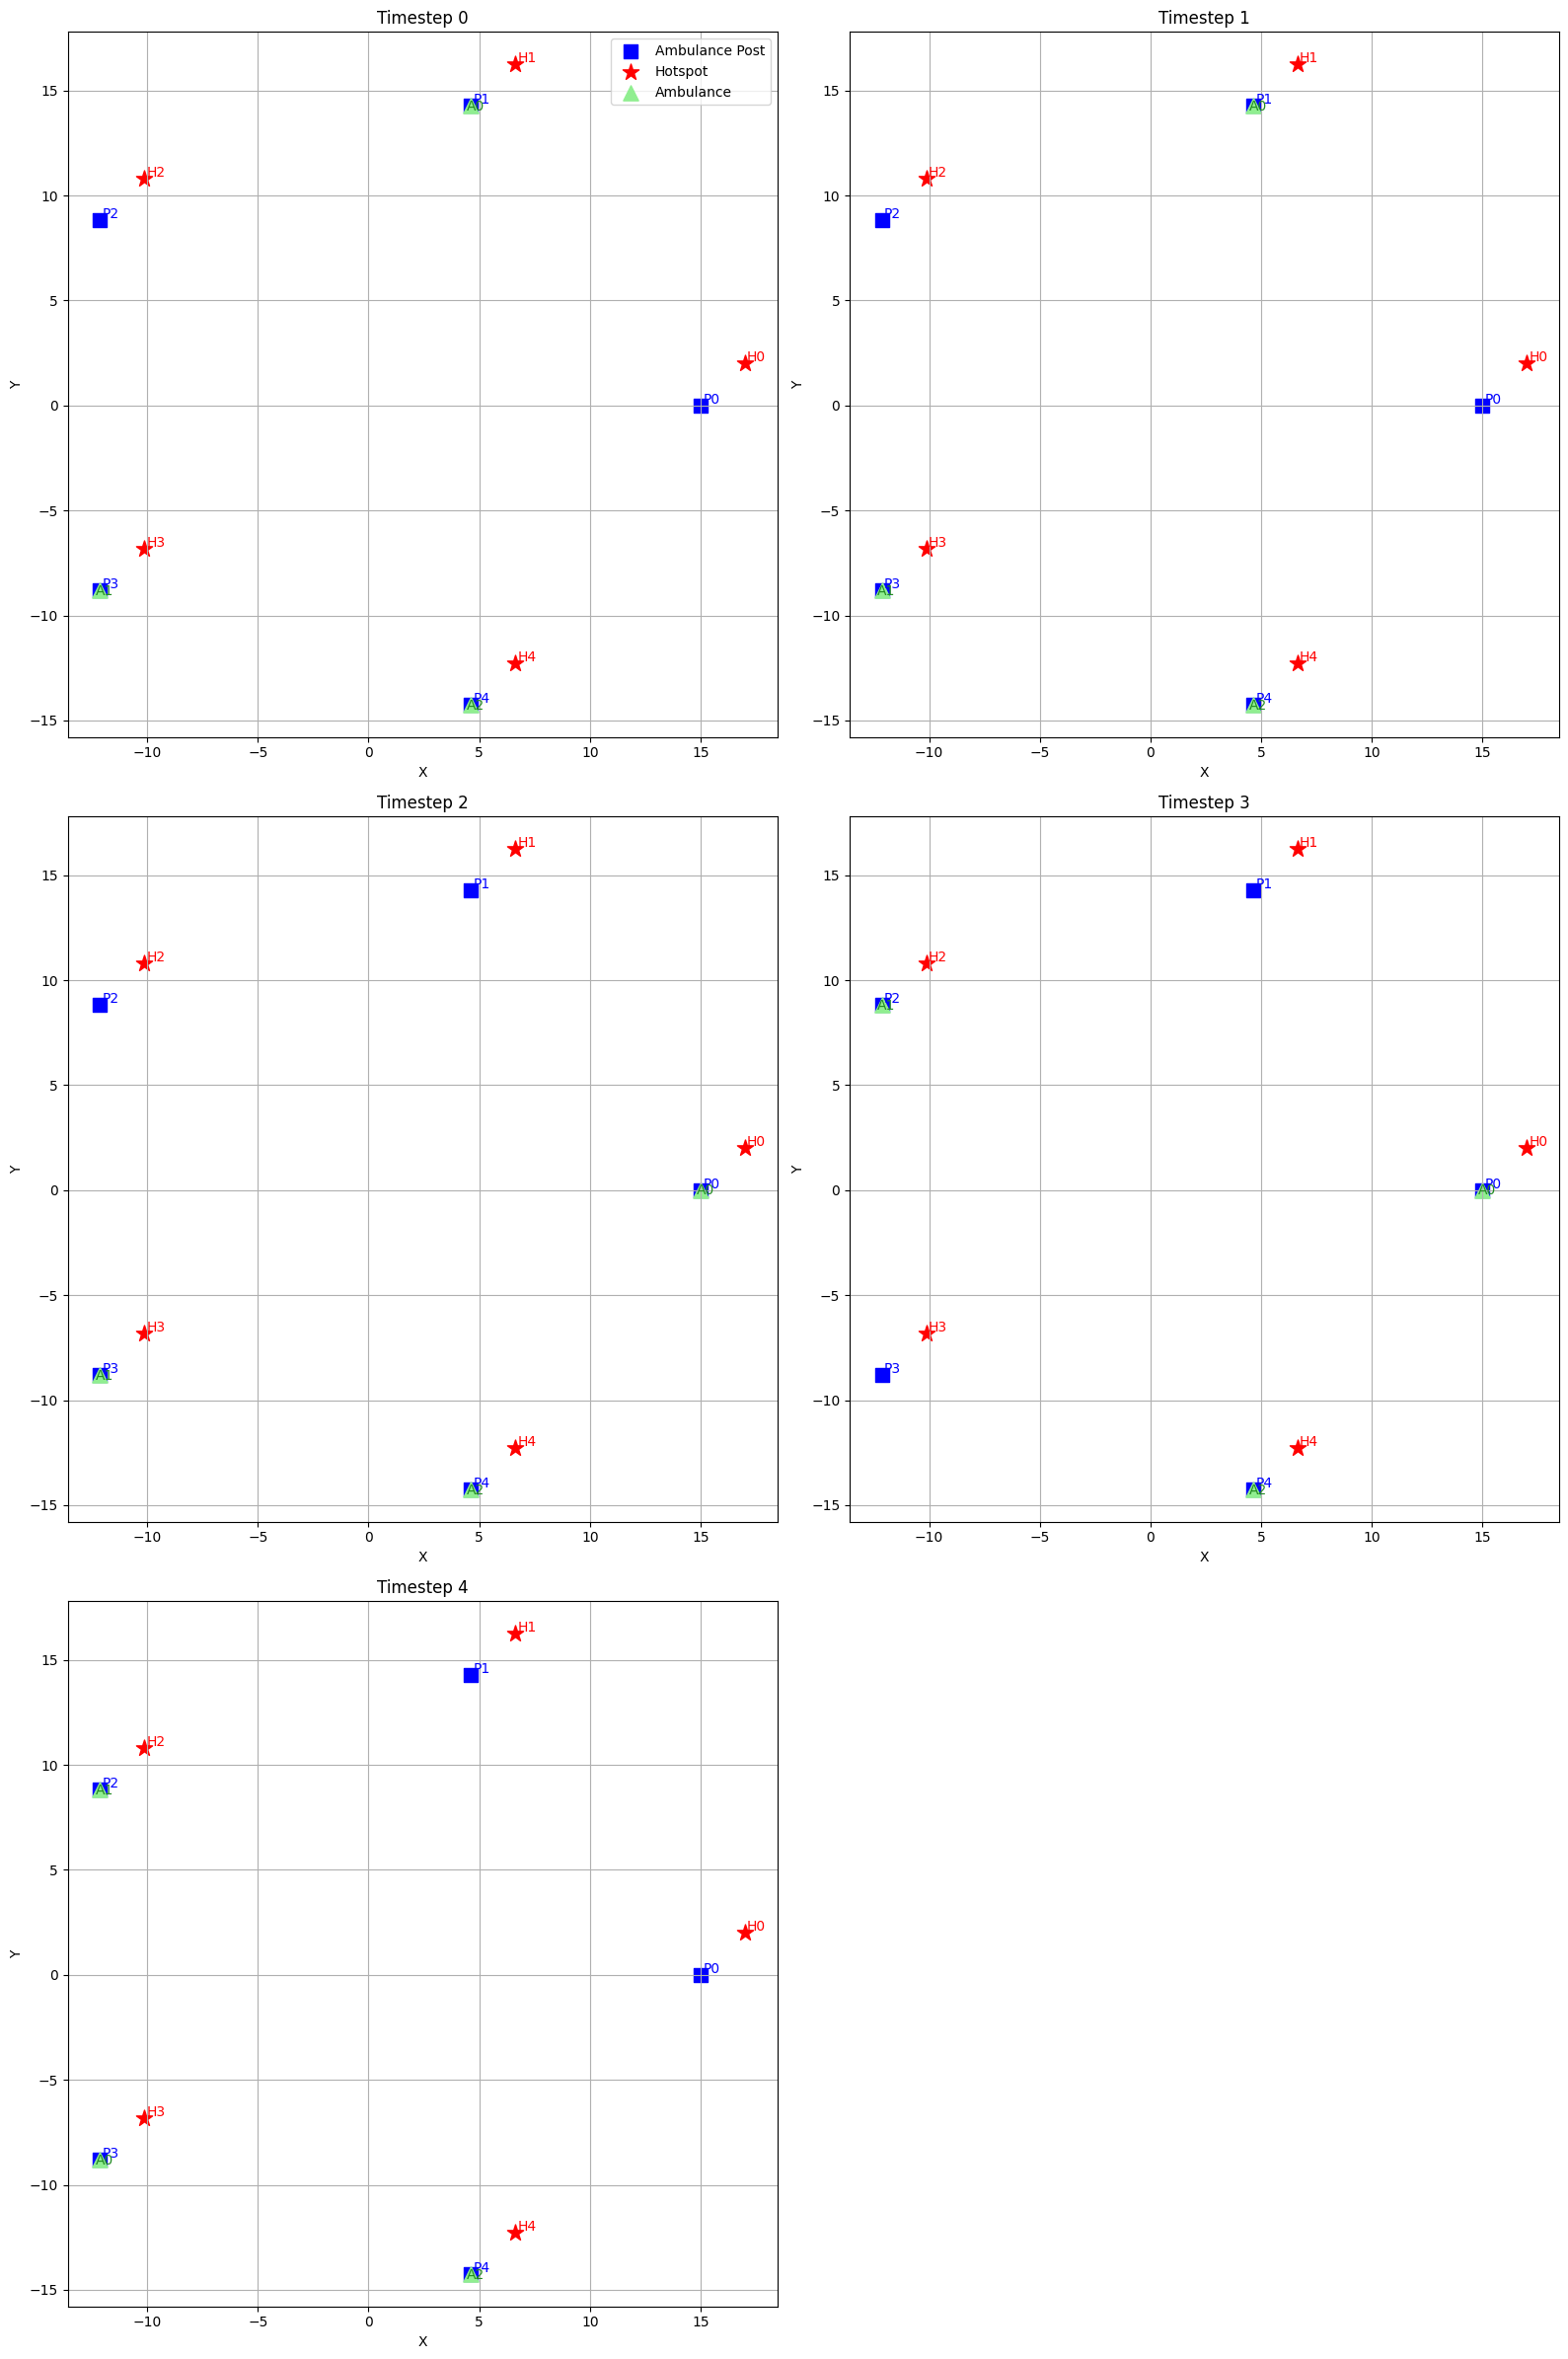

In [161]:
import numpy as np
# Generate pentagon vertices for hospitals and ambulance posts
def pentagon_vertices(center, radius):
    angles = np.linspace(0, 2*np.pi, 6)[:-1]  # 5 points
    return [(center[0] + radius * np.cos(a), center[1] + radius * np.sin(a)) for a in angles]

center = (0, 0)
radius = 15
hospitals = pentagon_vertices(center, radius)
ambulance_posts = hospitals.copy()

# Place hotspots near each post (offset slightly)
hotspot_offset = 2
call_hotspots = [(x + hotspot_offset, y + hotspot_offset) for (x, y) in ambulance_posts]

# J_k: ith hotspot covered by ith post only
J_k = {k: [k] for k in range(5)}

# Run simulation for 5 timesteps
assignment_history =run_simulation(
    num_timesteps=5,
    num_ambulances=3,
    ambulance_posts=ambulance_posts,
    call_hotspots=call_hotspots,
    J_k=J_k,
    calculate_c_fn=calculate_c,
    calculate_b_fn=calculate_b,
    )

In [136]:
assignment_history

[[(0, 1), (1, 3), (2, 4)],
 [(0, 1), (1, 3), (2, 4)],
 [(0, 1), (1, 3), (2, 4)],
 [(0, 0), (1, 2), (2, 4)],
 [(0, 0), (1, 2), (2, 4)]]